# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

In [49]:
# First import the required libraries
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

## The key drivers for used car prices may include the following 
### The model, make and year of the car
### The mileage of the car etc.

### From the given dataset our goal is to identify the factors which determin the used car price. There are so many parameters at play here but not all those parameters are detrimental to decide the price of the car. We need to understand the data and reduce the principal components and come up with a feature set which is most impactful. Model the problem on the reduced feature set using various ML techniques like LinearRegression, LogisticRegression etc. to determine prices of a used car based on it's features.

In [3]:
df = pd.read_csv('data/vehicles.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [10]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

## Following are main points for data understanding

### 1. Collect the data
### 2. If there are null data fields then we can't use it. Filter them out.
### 3. Check if the data has all the necessary features which logically make sense to determine the price of the used cars.
### 4. Check if we have enough non null data to model the problem.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

## Following are the steps involved in the data processing
### Clean the data, remove all the null data fields
### Remove the columns which are not going to make any impact to the car price e.g. VIN and id



In [56]:
df = pd.read_csv('data/vehicles.csv')

In [57]:
# Remove the null rows
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 34868 entries, 126 to 426836
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            34868 non-null  int64  
 1   region        34868 non-null  str    
 2   price         34868 non-null  int64  
 3   year          34868 non-null  float64
 4   manufacturer  34868 non-null  str    
 5   model         34868 non-null  str    
 6   condition     34868 non-null  str    
 7   cylinders     34868 non-null  str    
 8   fuel          34868 non-null  str    
 9   odometer      34868 non-null  float64
 10  title_status  34868 non-null  str    
 11  transmission  34868 non-null  str    
 12  VIN           34868 non-null  str    
 13  drive         34868 non-null  str    
 14  size          34868 non-null  str    
 15  type          34868 non-null  str    
 16  paint_color   34868 non-null  str    
 17  state         34868 non-null  str    
dtypes: float64(2), int64(2), str(14)
memory

In [58]:
# Columns which are sure to not impact the price of the car
# VIN, id - remove these columns

# Column 'region' has too much varied data to make sense for the model. The one hot or pririty encoding is not going to help here. Better to remove this column

df.drop(columns=['VIN','id', 'region'], inplace=True)
df.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
126,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,rwd,full-size,van,white,al
127,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,rwd,full-size,van,white,al
128,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,rwd,full-size,van,white,al
215,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,fwd,compact,sedan,blue,al
219,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,rwd,mid-size,sedan,white,al


In [74]:
pd.reset_option('display.max_rows')
df['manufacturer'].value_counts()

# There are 41 car manufacturers, doing one hot encoding would result in a sparse data and it elevates the risks of overfitting.
# Car manufacturer brand is important for price therefore replacing the average price of that model as the manufacture

df['manufacturer'] = df['manufacturer'].map(df.groupby('manufacturer')['price'].mean().round(2))
df.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
126,0,2018.0,17593.19,express cargo van,like new,6,gas,68472.0,clean,automatic,rwd,full-size,van,white,al
127,0,2019.0,17593.19,express cargo van,like new,6,gas,69125.0,clean,automatic,rwd,full-size,van,white,al
128,0,2018.0,17593.19,express cargo van,like new,6,gas,66555.0,clean,automatic,rwd,full-size,van,white,al
215,4000,2002.0,13351.63,echo,excellent,4,gas,155000.0,clean,automatic,fwd,compact,sedan,blue,al
219,2500,1995.0,13025.42,525i,fair,6,gas,110661.0,clean,automatic,rwd,mid-size,sedan,white,al


In [75]:
df['model'].value_counts()

model
f-150             943
silverado 1500    929
1500              482
2500              332
sierra 1500       330
                 ... 
avenger, se         1
tucson, gls         1
f150, xlt           1
f150, platinum      1
cruze, 2lt          1
Name: count, Length: 5109, dtype: int64

In [59]:
# Modify the cylinder column to have a numerical value, change the 'other' cylinder to -1 value
df['cylinders'] = df['cylinders'].apply(lambda x : x.split()[0])
df['cylinders'].value_counts()

# Remove the entries(rows) where the cylinder value is 'other'
df = df.loc[df['cylinders'] != 'other']
df['cylinders'].value_counts()



cylinders
6     11618
4     11302
8     10928
10      565
5       281
3        67
12       11
Name: count, dtype: int64

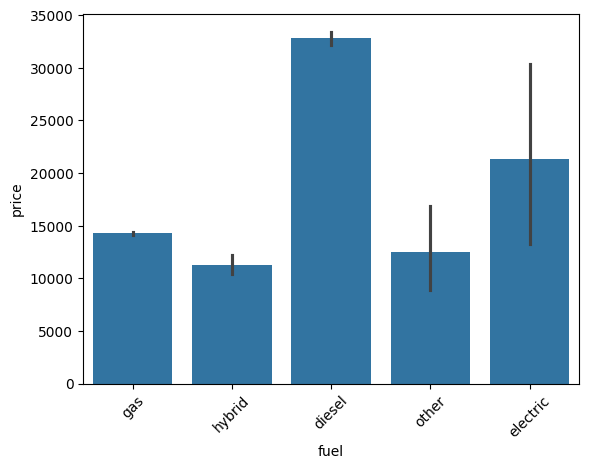

<Figure size 1200x800 with 0 Axes>

In [34]:
# Have the bar plot of the dfifferent fields to check the distribution of column values
sns.barplot(data=df, x='fuel', y='price')
plt.xticks(rotation=45)
plt.figure(figsize=(12,8))
plt.show()
#plt.title('Barplot of ')

# Conclusion: 4wd generally has higher price


In [53]:
# Split the test and train data
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X,y)
print(X_train.shape, y_train.shape)



(26079, 15) (26079,)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [ ]:
# Model1 - LinearRegression

In [54]:
lr = LinearRegression().fit(X_train, y_train)


ValueError: could not convert string to float: 'oklahoma city'

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.